# Model Comparison V2 — Stock Direction Prediction

**Doel**: voorspel of een stock morgen omhoog (1) of omlaag (0) gaat,
voor alle stocks in `DimStock`, op basis van:
- prijs/volume features uit `FactMarketData`
- macro-economische features uit `FactEcon`
- **sentiment uit de echte tekst** van tweets (`DimTwitter.Text`) en nieuws
  (`FactNews.Headline + Abstract`), gescoord met VADER.

## Data overzicht (uit DDL)

| Tabel            | Wat                                                          |
|------------------|--------------------------------------------------------------|
| `DimDate`        | `DateKey` (PK), `FullDateAlternateKey` (DATE), kalendermeta  |
| `DimStock`       | `StockKey` VARCHAR(10) (PK), `StockName`, `Type`             |
| `FactMarketData` | OHLCV per (DateKey, StockKey)                                |
| `FactEcon`       | Macro-econ per `DateKey` (USD, OIL, VIX, CPI, …)             |
| `DimTwitter`     | `TweetID`, `DateKey`, `[Text]`, `influenceScore`             |
| `FactNews`       | `DateKey`, `Headline`, `Abstract`, `influenceScore`          |
|                  | (let op: `NewsKey` ontbreekt in deployed schema — niet nodig)|

**Robust join**: we doen `LEFT JOIN DimStock` en vangen ontbrekende rijen
op met `COALESCE` zodat `StockName` als fallback werkt wanneer `StockKey`
problemen geeft.

## Modellen

1. **Majority class**     — baseline
2. **Logistic Regression**— lineair
3. **Random Forest**      — tabular ML
4. **XGBoost**            — gradient boosting
5. **LightGBM**           — gradient boosting
6. **MLP**                — dense NN
7. **1D-CNN**             — sequence
8. **GRU**                — sequence
9. **LSTM**               — sequence
10. **CNN+LSTM**          — sequence (Conv1d → LSTM stack)

## Metrics

Per model loggen we **train_acc**, **val_acc**, **test_acc**,
**precision**, **recall**, **F1**, **ROC-AUC**, **MAE**, **MAPE**, **Brier**.

> **Belangrijk**: voor je deze notebook commit, doe *Cell → All Output → Clear*
> in Jupyter. Grote DataFrame outputs kunnen het bestand corrupten op de Windows mount.

## 1. Setup & imports

In [27]:
import os, sys, json, warnings, time, re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "comparison" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS = Path(PROJECT_ROOT) / "model" / "comparison" / "artifacts_v2"
PER_STOCK = ARTIFACTS / "per_stock"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
PER_STOCK.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Artifacts:   ", ARTIFACTS)

Project root: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026
Artifacts:    c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_absolute_error, brier_score_loss,
    confusion_matrix,
)
from sklearn.dummy import DummyClassifier

def _try_import(name):
    try: return __import__(name), True
    except ImportError: return None, False

xgb, HAS_XGB = _try_import("xgboost")
lgb, HAS_LGB = _try_import("lightgbm")
torch, HAS_TORCH = _try_import("torch")
print(f"XGBoost:  {'OK' if HAS_XGB else 'MISSING'}")
print(f"LightGBM: {'OK' if HAS_LGB else 'MISSING'}")
print(f"PyTorch:  {'OK' if HAS_TORCH else 'MISSING'}")

XGBoost:  OK
LightGBM: OK
PyTorch:  OK


In [29]:
# VADER sentiment
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    HAS_VADER = True
    vader = SentimentIntensityAnalyzer()
except ImportError:
    HAS_VADER = False
    print("pip install vaderSentiment")
print(f"VADER: {'OK' if HAS_VADER else 'MISSING'}")

VADER: OK


## 2. Database connectie + robust query helper

In [30]:
from database.connectie.connectie import get_engine, getData
engine = get_engine()

with engine.connect() as conn:
    from sqlalchemy import text
    n = conn.execute(text("SELECT COUNT(*) FROM FactMarketData")).scalar()
    print(f"FactMarketData rijen: {n:,}")

def get_or_die(query: str, name: str) -> pd.DataFrame:
    df = getData(engine=engine, query=query)
    if df is None:
        raise RuntimeError(f"Query '{name}' faalde - check kolomnamen vs deployed schema")
    return df

FactMarketData rijen: 26,127


## 3. Market data + macro econ

We selecteren OHLCV uit `FactMarketData` en joinen met `FactEcon` (macro)
en `DimStock` (voor `StockName`). `LTRIM/RTRIM` op `StockKey` om eventuele
spaties weg te halen, en `COALESCE` op `StockName` zorgt dat we **altijd
een bruikbare identifier** hebben — zelfs als de DimStock-join voor een
ticker faalt.

In [31]:
SQL_MARKET = '''
SELECT
    m.DateKey,
    d.FullDateAlternateKey                              AS [Date],
    LTRIM(RTRIM(m.StockKey))                            AS StockKey,
    COALESCE(NULLIF(LTRIM(RTRIM(s.StockName)), ''),
             LTRIM(RTRIM(m.StockKey)))                  AS StockName,
    s.[Type]                                            AS StockType,
    CAST(m.[Open]  AS FLOAT)                            AS [Open],
    CAST(m.High    AS FLOAT)                            AS High,
    CAST(m.Low     AS FLOAT)                            AS Low,
    CAST(m.[Close] AS FLOAT)                            AS [Close],
    CAST(m.Volume  AS FLOAT)                            AS Volume,
    CAST(e.USD                  AS FLOAT) AS USD,
    CAST(e.OIL                  AS FLOAT) AS OIL,
    CAST(e.VIX                  AS FLOAT) AS VIX,
    CAST(e.YieldSpread          AS FLOAT) AS YieldSpread,
    CAST(e.InfExpectation       AS FLOAT) AS InfExpectation,
    CAST(e.FinStress            AS FLOAT) AS FinStress,
    CAST(e.FedFundsRate         AS FLOAT) AS FedFundsRate,
    CAST(e.FedBalanceSheet      AS FLOAT) AS FedBalanceSheet,
    CAST(e.CPI                  AS FLOAT) AS CPI,
    CAST(e.PPI                  AS FLOAT) AS PPI,
    CAST(e.Consumer_Confidence  AS FLOAT) AS Consumer_Confidence
FROM FactMarketData m
JOIN DimDate     d ON d.DateKey = m.DateKey
LEFT JOIN DimStock s ON LTRIM(RTRIM(s.StockKey)) = LTRIM(RTRIM(m.StockKey))
LEFT JOIN FactEcon e ON e.DateKey = m.DateKey
WHERE m.StockKey IS NOT NULL AND LEN(LTRIM(RTRIM(m.StockKey))) > 0
ORDER BY m.StockKey, d.FullDateAlternateKey
'''
market_df = get_or_die(SQL_MARKET, "market")
market_df["Date"] = pd.to_datetime(market_df["Date"])

# Kies beste identifier: StockName als die ingevuld is, anders StockKey
market_df["stock_id"] = market_df["StockName"].fillna(market_df["StockKey"]).astype(str)

print(f"market_df: {len(market_df):,} rijen")
print(f"Unieke stocks via StockKey:  {market_df['StockKey'].nunique()}")
print(f"Unieke stocks via StockName: {market_df['StockName'].nunique()}")
print(f"Periode: {market_df['Date'].min().date()} -> {market_df['Date'].max().date()}")
print(f"\nStocks (stock_id):")
for sid, g in market_df.groupby("stock_id"):
    print(f"  {sid:30s}  {len(g):>5} rijen")

market_df: 26,184 rijen
Unieke stocks via StockKey:  10
Unieke stocks via StockName: 10
Periode: 2016-01-04 -> 2026-05-04

Stocks (stock_id):
  Anheuser-Busch InBev SA/NV       2645 rijen
  BEL 20                           2644 rijen
  Chevron Corporation              2601 rijen
  Exxon Mobil Corporation          2601 rijen
  KBC Group NV                     2645 rijen
  Lockheed Martin Corporation      2601 rijen
  S&P 500                          2601 rijen
  SPDR Gold Shares                 2601 rijen
  State Street Energy Select Sector SPDR ETF   2601 rijen
  UCB SA                           2644 rijen


## 4. Tekst van tweets en nieuws ophalen

We selecteren **bewust geen `NewsKey`** want die kolom ontbreekt soms in
het deployed schema.

In [32]:
SQL_TWEETS = '''
SELECT d.FullDateAlternateKey AS [Date],
       t.[Text],
       COALESCE(CAST(t.influenceScore AS FLOAT), 0) AS influence
FROM DimTwitter t
JOIN DimDate d ON d.DateKey = t.DateKey
WHERE t.[Text] IS NOT NULL AND LEN(t.[Text]) > 0
'''
SQL_NEWS = '''
SELECT d.FullDateAlternateKey AS [Date],
       COALESCE(n.Headline, '') + ' ' + COALESCE(n.Abstract, '') AS [Text],
       COALESCE(CAST(n.influenceScore AS FLOAT), 0) AS influence
FROM FactNews n
JOIN DimDate d ON d.DateKey = n.DateKey
WHERE (n.Headline IS NOT NULL OR n.Abstract IS NOT NULL)
'''
tweets_df = get_or_die(SQL_TWEETS, "tweets")
news_df   = get_or_die(SQL_NEWS,   "news")
tweets_df["Date"] = pd.to_datetime(tweets_df["Date"])
news_df["Date"]   = pd.to_datetime(news_df["Date"])
print(f"tweets: {len(tweets_df):,}  |  news: {len(news_df):,}")

tweets: 26,122  |  news: 252,947


## 5. VADER sentiment scoring + tekst-features

Per text item:
- VADER's compound, pos, neg, neu scores
- aantal `$TICKER` mentions, exclamations, ALL-CAPS ratio
- aantal bullish/bearish keywords

In [33]:
BULLISH = {"rally","surge","beat","upgrade","outperform","bullish",
           "growth","soar","jump","gain","record","strong","profit"}
BEARISH = {"crash","plunge","miss","downgrade","underperform","bearish",
           "decline","fall","drop","loss","weak","warning","lawsuit",
           "investigation","default","bankruptcy"}

TICKER_RE = re.compile(r"\$[A-Z]{1,5}\b")
WORD_RE   = re.compile(r"\b[a-zA-Z']+\b")
EXCL_RE   = re.compile(r"!")

def text_features(t):
    if not isinstance(t, str) or not t:
        return {"v_compound":0,"v_pos":0,"v_neg":0,"v_neu":1,
                "n_tickers":0,"n_excl":0,"caps_ratio":0,"n_words":0,"n_bull":0,"n_bear":0}
    if HAS_VADER:
        v = vader.polarity_scores(t)
    else:
        v = {"compound":0,"pos":0,"neg":0,"neu":1}
    words = WORD_RE.findall(t)
    n_words = len(words)
    caps = sum(1 for w in words if len(w)>1 and w.isupper())
    caps_ratio = caps/n_words if n_words else 0
    lower = t.lower()
    return {"v_compound":v["compound"],"v_pos":v["pos"],
            "v_neg":v["neg"],"v_neu":v["neu"],
            "n_tickers":len(TICKER_RE.findall(t)),
            "n_excl":len(EXCL_RE.findall(t)),
            "caps_ratio":caps_ratio,"n_words":n_words,
            "n_bull":sum(1 for kw in BULLISH if kw in lower),
            "n_bear":sum(1 for kw in BEARISH if kw in lower)}

def score_df(df):
    feats = pd.DataFrame.from_records(df["Text"].map(text_features).tolist(), index=df.index)
    return pd.concat([df.drop(columns=["Text"]), feats], axis=1)

print("Scoring tweets..."); t0 = time.time()
tweets_scored = score_df(tweets_df)
print(f"  done in {time.time()-t0:.1f}s ({len(tweets_scored):,} items)")
print("Scoring news...");   t0 = time.time()
news_scored   = score_df(news_df)
print(f"  done in {time.time()-t0:.1f}s ({len(news_scored):,} items)")

Scoring tweets...
  done in 7.4s (26,122 items)
Scoring news...
  done in 39.8s (252,947 items)


## 6. Daily aggregatie van sentiment

Per dag:
- influence-gewogen gemiddelde compound (sterker signaal als invloedrijke
  accounts spreken)
- standaarddeviatie (consensus vs verdeeldheid)
- counts en sums van tickers, exclamations, bullish/bearish keywords

In [34]:
def aggregate_daily(df, prefix):
    df = df.copy()
    df["dnorm"] = df["Date"].dt.normalize()
    g = df.groupby("dnorm")
    weights = df["influence"]

    def wmean(col):
        v = df[col]
        w = weights.where(weights > 0, 0)
        num = (v * w).groupby(df["dnorm"]).sum()
        den = w.groupby(df["dnorm"]).sum().replace(0, np.nan)
        return (num / den).fillna(g[col].mean())

    out = pd.DataFrame({
        f"{prefix}_compound_mean":   g["v_compound"].mean(),
        f"{prefix}_compound_wmean":  wmean("v_compound"),
        f"{prefix}_compound_std":    g["v_compound"].std(),
        f"{prefix}_pos_sum":         g["v_pos"].sum(),
        f"{prefix}_neg_sum":         g["v_neg"].sum(),
        f"{prefix}_n_items":         g.size(),
        f"{prefix}_n_tickers":       g["n_tickers"].sum(),
        f"{prefix}_n_excl":          g["n_excl"].sum(),
        f"{prefix}_caps_ratio_mean": g["caps_ratio"].mean(),
        f"{prefix}_n_bull":          g["n_bull"].sum(),
        f"{prefix}_n_bear":          g["n_bear"].sum(),
        f"{prefix}_bull_minus_bear": g["n_bull"].sum() - g["n_bear"].sum(),
    })
    out.index.name = "Date"
    return out.reset_index()

tw_daily   = aggregate_daily(tweets_scored, "tw")
news_daily = aggregate_daily(news_scored,   "news")
print(f"tw_daily: {tw_daily.shape}, news_daily: {news_daily.shape}")

tw_daily: (1363, 13), news_daily: (3760, 13)


## 7. Joinen + feature engineering

Sentiment join op `Date`. Forward-fill voor dagen zonder posts.
Per stock: log_return, return_5d/10d, rolling mean/std, RSI, Bollinger, vol z-score.

In [35]:
df = market_df.merge(tw_daily, on="Date", how="left")
df = df.merge(news_daily, on="Date", how="left")

sent_cols = [c for c in df.columns if c.startswith(("tw_", "news_"))]
df[sent_cols] = df.sort_values(["stock_id","Date"]).groupby("stock_id")[sent_cols].ffill()
df[sent_cols] = df[sent_cols].fillna(0)
print(f"df na merge: {df.shape}")

df na merge: (26184, 46)


In [36]:
def add_engineered(g):
    g = g.sort_values("Date").copy()
    c = g["Close"]
    g["log_return"]     = np.log(c / c.shift(1))
    g["return_5d"]      = c.pct_change(5)
    g["return_10d"]     = c.pct_change(10)
    g["rolling_mean_5"] = c.rolling(5).mean()
    g["rolling_std_5"]  = c.rolling(5).std()
    g["rolling_std_20"] = c.rolling(20).std()
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    g["rsi_14"] = (100 - 100/(1+rs)).fillna(50)
    m20 = c.rolling(20).mean()
    s20 = c.rolling(20).std().replace(0, np.nan)
    g["bollinger_pos"] = ((c - m20) / s20).fillna(0)
    v = g["Volume"]
    g["vol_zscore"] = ((v - v.rolling(20).mean()) / v.rolling(20).std().replace(0, np.nan)).fillna(0)
    return g

# Pandas 2.2+ veilige loop (groupby.apply strips de groupby kolom)
_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_engineered(_g)
    _g2["stock_id"] = _sid
    _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
print(f"df na engineering: {df.shape}")

df na engineering: (26184, 55)


## 8. Target

Binary classification: `target = 1` als `Close[t+1] > Close[t]`, anders 0.
We bewaren ook `y_return` (forward return) voor MAE/MAPE op een echte
regressie-grootheid.

In [37]:
HORIZON = 1
THRESHOLD = 0.0

def add_target(g):
    g = g.sort_values("Date").copy()
    fut = g["Close"].shift(-HORIZON)
    fut_ret = fut / g["Close"] - 1
    g["y_return"] = fut_ret
    g["target"] = (fut_ret > THRESHOLD).astype(float)
    g.loc[fut.isna(), "target"] = np.nan
    g.loc[fut.isna(), "y_return"] = np.nan
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_target(_g)
    _g2["stock_id"] = _sid
    _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
df = df.dropna(subset=["target"]).reset_index(drop=True)
print(f"Final df: {df.shape}")
print(f"Class balance: {df['target'].mean():.3f} positief")

Final df: (26161, 57)
Class balance: 0.526 positief


## 9. Tijds-gebaseerde train/val/test split

In [38]:
dates_sorted = np.sort(df["Date"].unique())
n = len(dates_sorted)
TRAIN_END = pd.Timestamp(dates_sorted[int(n*0.75)-1])
VAL_END   = pd.Timestamp(dates_sorted[int(n*0.90)-1])

train_df = df[df["Date"] <= TRAIN_END].copy()
val_df   = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df  = df[df["Date"] > VAL_END].copy()

print(f"Train: {len(train_df):>6,}  ({train_df['Date'].min().date()} -> {TRAIN_END.date()})")
print(f"Val:   {len(val_df):>6,}  ({(TRAIN_END + pd.Timedelta(days=1)).date()} -> {VAL_END.date()})")
print(f"Test:  {len(test_df):>6,}  ({(VAL_END + pd.Timedelta(days=1)).date()} -> {test_df['Date'].max().date()})")

Train: 19,587  (2016-01-04 -> 2023-09-22)
Val:    3,908  (2023-09-23 -> 2025-04-10)
Test:   2,666  (2025-04-11 -> 2026-05-01)


## 10. Feature matrices

In [39]:
META_COLS = {"DateKey","Date","StockKey","StockName","StockType","stock_id","target","y_return"}
PRICE_FEATURES = ["Open","High","Low","Close","Volume",
                  "log_return","return_5d","return_10d",
                  "rolling_mean_5","rolling_std_5","rolling_std_20",
                  "rsi_14","bollinger_pos","vol_zscore",
                  "USD","OIL","VIX","YieldSpread","InfExpectation",
                  "FinStress","FedFundsRate","FedBalanceSheet","CPI","PPI",
                  "Consumer_Confidence"]
SENT_FEATURES = [c for c in df.columns if c.startswith(("tw_","news_"))]
PRICE_FEATURES = [c for c in PRICE_FEATURES if c in df.columns]
FEATURE_COLS = PRICE_FEATURES + SENT_FEATURES
print(f"Price features: {len(PRICE_FEATURES)}  Sentiment: {len(SENT_FEATURES)}")
print(f"Totaal: {len(FEATURE_COLS)}")

Price features: 25  Sentiment: 24
Totaal: 49


In [40]:
# Tabular: stock_id one-hot
def with_stock_dummies(d):
    d = d.copy()
    return pd.get_dummies(d, columns=["stock_id"], prefix="stk", drop_first=False)

train_tab = with_stock_dummies(train_df)
val_tab   = with_stock_dummies(val_df)
test_tab  = with_stock_dummies(test_df)
all_cols = sorted(set(train_tab.columns) | set(val_tab.columns) | set(test_tab.columns))
for d in (train_tab, val_tab, test_tab):
    for c in all_cols:
        if c not in d.columns: d[c] = 0
stk_cols = [c for c in train_tab.columns if c.startswith("stk_")]
TAB_FEATURES = FEATURE_COLS + stk_cols

X_tr = np.nan_to_num(train_tab[TAB_FEATURES].astype(float).values)
y_tr = train_tab["target"].astype(int).values
X_va = np.nan_to_num(val_tab[TAB_FEATURES].astype(float).values)
y_va = val_tab["target"].astype(int).values
X_te = np.nan_to_num(test_tab[TAB_FEATURES].astype(float).values)
y_te = test_tab["target"].astype(int).values

# Bewaar stock_id en Date voor per-stock plots later
test_stock_ids = test_df["stock_id"].values
test_dates     = test_df["Date"].values
test_close     = test_df["Close"].values

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)
print(f"X_tr: {X_tr.shape}, X_va: {X_va.shape}, X_te: {X_te.shape}")

X_tr: (19587, 59), X_va: (3908, 59), X_te: (2666, 59)


## 11. Evaluatie helper met alle metrics

Per model loggen we **train_acc, val_acc, test_acc, precision, recall, F1,
ROC-AUC, MAE, MAPE, Brier**, en bewaren we de test predictions zodat we
later per-stock plots kunnen maken.

In [41]:
results = []
predictions = {}  # model_name -> dict met test predictions voor plotting

def safe_mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def log_metrics(name, y_tr_p, y_va_p, y_te_p, y_te_proba,
                stock_ids=None, dates=None, close=None,
                y_tr_true=None, y_va_true=None, y_te_true=None):
    """y_*_true overrides default y_tr/y_va/y_te (use voor sequence modellen
    waar de targets korter zijn dan de tabular targets)."""
    yt_tr = y_tr_true if y_tr_true is not None else y_tr
    yt_va = y_va_true if y_va_true is not None else y_va
    yt_te = y_te_true if y_te_true is not None else y_te

    rec = {"model": name}
    if y_tr_p is not None:
        rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"] = accuracy_score(yt_va, y_va_p)
        rec["val_f1"]  = f1_score(yt_va, y_va_p, zero_division=0)
    rec["test_acc"]  = accuracy_score(yt_te, y_te_p)
    rec["precision"] = precision_score(yt_te, y_te_p, zero_division=0)
    rec["recall"]    = recall_score(yt_te, y_te_p, zero_division=0)
    rec["f1"]        = f1_score(yt_te, y_te_p, zero_division=0)
    if y_te_proba is not None:
        rec["roc_auc"] = roc_auc_score(yt_te, y_te_proba)
        rec["mae"]     = mean_absolute_error(yt_te, y_te_proba)
        rec["mape"]    = safe_mape(yt_te, y_te_proba)
        rec["brier"]   = brier_score_loss(yt_te, y_te_proba)
    results.append(rec)
    msg = "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v, float))
    print(f"  {name:25s}  {msg}")
    predictions[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates if dates is not None else test_dates,
        "Close":    close if close is not None else test_close,
        "y_true":   yt_te,
        "y_pred":   y_te_p,
        "y_proba":  y_te_proba if y_te_proba is not None else np.full_like(yt_te, 0.5, dtype=float),
    }
    return rec

## 12. Tabular modellen

### 12.1 Majority class baseline

In [42]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_tr)
log_metrics("Majority class",
            dummy.predict(X_tr_s), dummy.predict(X_va_s),
            dummy.predict(X_te_s), dummy.predict_proba(X_te_s)[:,1])

  Majority class             train_acc=0.521  val_acc=0.540  val_f1=0.701  test_acc=0.540  precision=0.540  recall=1.000  f1=0.701  roc_auc=0.500  mae=0.460  mape=46024.006  brier=0.460


{'model': 'Majority class',
 'train_acc': 0.5209577781181396,
 'val_acc': 0.5396622313203685,
 'val_f1': 0.7010137942496261,
 'test_acc': 0.5397599399849963,
 'precision': 0.5397599399849963,
 'recall': 1.0,
 'f1': 0.7010962241169306,
 'roc_auc': 0.5,
 'mae': 0.4602400600150037,
 'mape': 46024.00600150038,
 'brier': 0.4602400600150037}

### 12.2 Logistic Regression

In [43]:
logreg = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_tr)
log_metrics("Logistic Regression",
            logreg.predict(X_tr_s), logreg.predict(X_va_s),
            logreg.predict(X_te_s), logreg.predict_proba(X_te_s)[:,1])

  Logistic Regression        train_acc=0.531  val_acc=0.491  val_f1=0.446  test_acc=0.471  precision=0.519  recall=0.272  f1=0.357  roc_auc=0.498  mae=0.501  mape=21204.354  brier=0.262


{'model': 'Logistic Regression',
 'train_acc': 0.5314749578802267,
 'val_acc': 0.4907881269191402,
 'val_f1': 0.4456824512534819,
 'test_acc': 0.4711177794448612,
 'precision': 0.519205298013245,
 'recall': 0.27241139680333565,
 'f1': 0.35733819507748404,
 'roc_auc': 0.49753377362369616,
 'mae': 0.501088066209724,
 'mape': 21204.354191414295,
 'brier': 0.26224329439427047}

### 12.3 Random Forest

In [44]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                            class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_tr)
log_metrics("Random Forest",
            rf.predict(X_tr), rf.predict(X_va),
            rf.predict(X_te), rf.predict_proba(X_te)[:,1])

  Random Forest              train_acc=0.743  val_acc=0.495  val_f1=0.501  test_acc=0.481  precision=0.526  recall=0.392  f1=0.449  roc_auc=0.490  mae=0.501  mape=22657.746  brier=0.252


{'model': 'Random Forest',
 'train_acc': 0.7430949098892122,
 'val_acc': 0.4951381780962129,
 'val_f1': 0.5006327512022273,
 'test_acc': 0.48124531132783194,
 'precision': 0.5261194029850746,
 'recall': 0.3919388464211258,
 'f1': 0.44922341696535245,
 'roc_auc': 0.49047292984521873,
 'mae': 0.5011136798479511,
 'mape': 22657.745754363623,
 'brier': 0.25194577897238124}

### 12.4 XGBoost

In [45]:
if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_clf = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        eval_metric="logloss", n_jobs=-1, random_state=42,
        scale_pos_weight=(y_tr==0).sum() / max((y_tr==1).sum(), 1),
    )
    xgb_clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    log_metrics("XGBoost",
                xgb_clf.predict(X_tr), xgb_clf.predict(X_va),
                xgb_clf.predict(X_te), xgb_clf.predict_proba(X_te)[:,1])
else:
    print("XGBoost not installed - skip")

  XGBoost                    train_acc=0.749  val_acc=0.492  val_f1=0.478  test_acc=0.489  precision=0.534  recall=0.412  f1=0.465  roc_auc=0.504  mae=0.501  mape=21959.118  brier=0.260


### 12.5 LightGBM

In [46]:
if HAS_LGB:
    from lightgbm import LGBMClassifier
    lgb_clf = LGBMClassifier(
        n_estimators=500, num_leaves=31, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced",
    )
    lgb_clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])
    log_metrics("LightGBM",
                lgb_clf.predict(X_tr), lgb_clf.predict(X_va),
                lgb_clf.predict(X_te), lgb_clf.predict_proba(X_te)[:,1])
else:
    print("LightGBM not installed - skip")

  LightGBM                   train_acc=0.879  val_acc=0.499  val_f1=0.510  test_acc=0.488  precision=0.533  recall=0.413  f1=0.465  roc_auc=0.503  mae=0.500  mape=21784.123  brier=0.262


### 12.6 MLP

In [47]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu",
                    alpha=1e-3, max_iter=100, early_stopping=True,
                    validation_fraction=0.1, random_state=42).fit(X_tr_s, y_tr)
log_metrics("MLP",
            mlp.predict(X_tr_s), mlp.predict(X_va_s),
            mlp.predict(X_te_s), mlp.predict_proba(X_te_s)[:,1])

  MLP                        train_acc=0.663  val_acc=0.493  val_f1=0.528  test_acc=0.522  precision=0.557  recall=0.556  f1=0.557  roc_auc=0.522  mae=0.492  mape=23381.089  brier=0.285


{'model': 'MLP',
 'train_acc': 0.6631949762597641,
 'val_acc': 0.49334698055271237,
 'val_f1': 0.5278969957081545,
 'test_acc': 0.5221305326331583,
 'precision': 0.5574912891986062,
 'recall': 0.5559416261292565,
 'f1': 0.5567153792623522,
 'roc_auc': 0.5220674730538786,
 'mae': 0.4918875211729158,
 'mape': 23381.08915979803,
 'brier': 0.2848390982418587}

## 13. Sequence-data preparen

We bouwen sliding windows van `SEQ_LEN=20` dagen per stock. Elke sample
is `(stock_id, last_date, X[20, n_features], y)`.

In [48]:
SEQ_LEN = 20

def build_sequences(d):
    Xs, ys, sids, dts, closes = [], [], [], [], []
    stock_id_map = {s: i for i, s in enumerate(sorted(d["stock_id"].unique()))}
    for sid_str, g in d.groupby("stock_id", sort=False):
        g = g.sort_values("Date").reset_index(drop=True)
        if len(g) < SEQ_LEN: continue
        a = np.nan_to_num(g[FEATURE_COLS].astype(float).values)
        t = g["target"].astype(int).values
        d_arr = g["Date"].values
        c_arr = g["Close"].values
        for end in range(SEQ_LEN, len(g)):
            Xs.append(a[end-SEQ_LEN:end])
            ys.append(t[end-1])
            sids.append(sid_str)
            dts.append(d_arr[end-1])
            closes.append(c_arr[end-1])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            np.array(sids, dtype=object),
            np.array(dts, dtype="datetime64[ns]"),
            np.array(closes, dtype=np.float32),
            stock_id_map)

X_tr_seq, y_tr_seq, sid_tr, dt_tr, close_tr, stock_id_map = build_sequences(train_df)
X_va_seq, y_va_seq, sid_va, dt_va, close_va, _ = build_sequences(val_df)
X_te_seq, y_te_seq, sid_te, dt_te, close_te, _ = build_sequences(test_df)

# Schaal per feature op train
sc = StandardScaler().fit(X_tr_seq.reshape(-1, X_tr_seq.shape[-1]))
def _sc(X): return sc.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)
X_tr_seq, X_va_seq, X_te_seq = _sc(X_tr_seq), _sc(X_va_seq), _sc(X_te_seq)

# Map sid_strings naar int ids
def to_ids(sids_str):
    return np.array([stock_id_map.get(s, 0) for s in sids_str], dtype=np.int64)

sid_tr_i = to_ids(sid_tr)
sid_va_i = to_ids(sid_va)
sid_te_i = to_ids(sid_te)
print(f"Train: {X_tr_seq.shape}, Val: {X_va_seq.shape}, Test: {X_te_seq.shape}")

Train: (19387, 20, 49), Val: (3708, 20, 49), Test: (2466, 20, 49)


## 14. Sequence modellen (CNN, GRU, LSTM, CNN+LSTM)

In [49]:
if HAS_TORCH:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {DEVICE}")
    torch.manual_seed(42); np.random.seed(42)

    n_features = X_tr_seq.shape[-1]
    n_stocks = len(stock_id_map)
    EMB = 16

    def make_loader(*tensors, batch=128, shuffle=False):
        ds = TensorDataset(*[torch.from_numpy(t) for t in tensors])
        return DataLoader(ds, batch_size=batch, shuffle=shuffle)

    tr_ld = make_loader(X_tr_seq, sid_tr_i, y_tr_seq, batch=128, shuffle=True)
    va_ld = make_loader(X_va_seq, sid_va_i, y_va_seq, batch=256)
    te_ld = make_loader(X_te_seq, sid_te_i, y_te_seq, batch=256)
else:
    print("PyTorch missing - skipping sequence models")

Device: cpu


In [50]:
if HAS_TORCH:
    class SeqModel(nn.Module):
        def __init__(self, kind, in_dim, hidden=64, dropout=0.4):
            super().__init__()
            self.kind = kind
            self.emb = nn.Embedding(n_stocks, EMB)
            in_dim_c = in_dim + EMB
            if kind == "gru":
                self.core = nn.GRU(in_dim_c, hidden, batch_first=True)
            elif kind == "lstm":
                self.core = nn.LSTM(in_dim_c, hidden, batch_first=True)
            elif kind == "cnn":
                self.core = nn.Sequential(
                    nn.Conv1d(in_dim_c, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.Conv1d(hidden, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.AdaptiveAvgPool1d(1),
                )
            elif kind == "cnn_lstm":
                # Conv1d extraheert lokale patronen, LSTM modelleert temporal dependencies
                self.cnn = nn.Sequential(
                    nn.Conv1d(in_dim_c, hidden, 3, padding=1),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                )
                self.core = nn.LSTM(hidden, hidden, batch_first=True)
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))

        def forward(self, x, sid):
            e = self.emb(sid).unsqueeze(1).expand(-1, x.size(1), -1)
            xin = torch.cat([x, e], dim=-1)
            if self.kind == "cnn":
                h = self.core(xin.transpose(1,2)).squeeze(-1)
            elif self.kind == "cnn_lstm":
                c = self.cnn(xin.transpose(1, 2)).transpose(1, 2)
                h, _ = self.core(c)
                h = h[:, -1]
            else:
                h, _ = self.core(xin)
                h = h[:, -1]
            return self.head(h).squeeze(-1)

In [51]:
if HAS_TORCH:
    pos_w = np.array([(y_tr_seq==0).sum() / max((y_tr_seq==1).sum(), 1)])
    print(f"Class balance pos_weight: {pos_w[0]:.3f}")

    histories = {}

    def train_seq(kind, epochs=20, lr=1e-3, patience=4, weight_decay=1e-4, verbose=True):
        model = SeqModel(kind, in_dim=n_features).to(DEVICE)
        n_params = sum(p.numel() for p in model.parameters())
        if verbose: print(f"  {kind}: {n_params:,} params")
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_w, device=DEVICE, dtype=torch.float32))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        best_va, best_state, p_no_improve = -1, None, 0
        history = []
        for ep in range(1, epochs+1):
            model.train()
            tr_correct, tr_n = 0, 0
            for x, sid, y in tr_ld:
                x,sid,y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)
                logits = model(x, sid)
                loss = loss_fn(logits, y)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
                tr_correct += ((torch.sigmoid(logits) >= 0.5).float() == y).sum().item()
                tr_n += y.size(0)
            sched.step()
            tr_acc = tr_correct / max(tr_n, 1)
            # validate
            model.eval()
            va_preds, va_ys = [], []
            with torch.no_grad():
                for x, sid, y in va_ld:
                    pr = torch.sigmoid(model(x.to(DEVICE), sid.to(DEVICE))).cpu().numpy()
                    va_preds.append((pr >= 0.5).astype(int)); va_ys.append(y.numpy())
            va_acc = accuracy_score(np.concatenate(va_ys), np.concatenate(va_preds))
            history.append({"epoch": ep, "train_acc": tr_acc, "val_acc": va_acc})
            if verbose and ep % 5 == 0:
                print(f"   epoch {ep:02d}  train={tr_acc:.3f}  val={va_acc:.3f}")
            if va_acc > best_va:
                best_va, p_no_improve = va_acc, 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                p_no_improve += 1
                if p_no_improve >= patience: break
        if best_state: model.load_state_dict(best_state)
        # Final preds on all sets
        def _predict(loader):
            preds, probas, ys = [], [], []
            model.eval()
            with torch.no_grad():
                for x, sid, y in loader:
                    pr = torch.sigmoid(model(x.to(DEVICE), sid.to(DEVICE))).cpu().numpy()
                    probas.append(pr); preds.append((pr>=0.5).astype(int)); ys.append(y.numpy())
            return (np.concatenate(ys), np.concatenate(preds), np.concatenate(probas))
        return _predict(tr_ld), _predict(va_ld), _predict(te_ld), history

Class balance pos_weight: 0.918


### 14.1 1D-CNN

In [52]:
if HAS_TORCH:
    (tr_y, tr_p, _), (va_y, va_p, _), (te_y, te_p, te_pr), hist = train_seq("cnn")
    histories["1D-CNN"] = hist
    log_metrics("1D-CNN", tr_p, va_p, te_p, te_pr,
                stock_ids=sid_te, dates=dt_te, close=close_te,
                y_tr_true=y_tr_seq, y_va_true=y_va_seq, y_te_true=y_te_seq)

  cnn: 25,377 params
   epoch 05  train=0.520  val=0.465
  1D-CNN                     train_acc=0.495  val_acc=0.523  val_f1=0.654  test_acc=0.525  precision=0.554  recall=0.576  f1=0.565  roc_auc=0.519  mae=0.499  mape=23222.662  brier=0.250


### 14.2 GRU

In [53]:
if HAS_TORCH:
    (tr_y, tr_p, _), (va_y, va_p, _), (te_y, te_p, te_pr), hist = train_seq("gru")
    histories["GRU"] = hist
    log_metrics("GRU", tr_p, va_p, te_p, te_pr,
                stock_ids=sid_te, dates=dt_te, close=close_te,
                y_tr_true=y_tr_seq, y_va_true=y_va_seq, y_te_true=y_te_seq)

  gru: 25,377 params
   epoch 05  train=0.531  val=0.502
  GRU                        train_acc=0.504  val_acc=0.528  val_f1=0.662  test_acc=0.529  precision=0.536  recall=0.896  f1=0.671  roc_auc=0.512  mae=0.496  mape=25378.813  brier=0.249


### 14.3 LSTM

In [54]:
if HAS_TORCH:
    (tr_y, tr_p, _), (va_y, va_p, _), (te_y, te_p, te_pr), hist = train_seq("lstm")
    histories["LSTM"] = hist
    log_metrics("LSTM", tr_p, va_p, te_p, te_pr,
                stock_ids=sid_te, dates=dt_te, close=close_te,
                y_tr_true=y_tr_seq, y_va_true=y_va_seq, y_te_true=y_te_seq)

  lstm: 33,761 params
   epoch 05  train=0.536  val=0.516
  LSTM                       train_acc=0.501  val_acc=0.516  val_f1=0.638  test_acc=0.519  precision=0.538  recall=0.719  f1=0.615  roc_auc=0.495  mae=0.498  mape=24798.837  brier=0.252


### 14.4 CNN+LSTM (de focus)

`Conv1d → LSTM` stack: de CNN extraheert lokale patronen uit de
feature-tijdreeks, en de LSTM modelleert daarna de temporele afhankelijkheden
over de hele sequence. Veelgebruikt in recente sentiment-papers.

In [55]:
if HAS_TORCH:
    (tr_y, tr_p, _), (va_y, va_p, _), (te_y, te_p, te_pr), hist = train_seq("cnn_lstm", epochs=25, patience=5)
    histories["CNN+LSTM"] = hist
    log_metrics("CNN+LSTM", tr_p, va_p, te_p, te_pr,
                stock_ids=sid_te, dates=dt_te, close=close_te,
                y_tr_true=y_tr_seq, y_va_true=y_va_seq, y_te_true=y_te_seq)

  cnn_lstm: 46,049 params
   epoch 05  train=0.534  val=0.496
  CNN+LSTM                   train_acc=0.512  val_acc=0.526  val_f1=0.641  test_acc=0.508  precision=0.529  recall=0.735  f1=0.615  roc_auc=0.481  mae=0.500  mape=23636.663  brier=0.250


## 15. Vergelijkingstabel + bar charts per metric

In [56]:
results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df.to_csv(ARTIFACTS / "results.csv", index=False)
print(f"Saved: {ARTIFACTS / 'results.csv'}")
print(results_df.round(4).to_string(index=False))

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\results.csv
              model  train_acc  val_acc  val_f1  test_acc  precision  recall     f1  roc_auc    mae       mape  brier
     Majority class     0.5210   0.5397  0.7010    0.5398     0.5398  1.0000 0.7011   0.5000 0.4602 46024.0060 0.4602
                GRU     0.5042   0.5283  0.6620    0.5292     0.5358  0.8961 0.6706   0.5123 0.4956 25378.8132 0.2492
             1D-CNN     0.4946   0.5235  0.6540    0.5247     0.5535  0.5762 0.5646   0.5194 0.4994 23222.6615 0.2500
                MLP     0.6632   0.4933  0.5279    0.5221     0.5575  0.5559 0.5567   0.5221 0.4919 23381.0892 0.2848
               LSTM     0.5011   0.5162  0.6382    0.5191     0.5377  0.7195 0.6154   0.4946 0.4984 24798.8367 0.2521
           CNN+LSTM     0.5122   0.5259  0.6411    0.5081     0.5289  0.7354 0.6153   0.4809 0.5000 23636.6633 0.2503
            XGBoost     0.7486   0.4916  0.4783    0.48

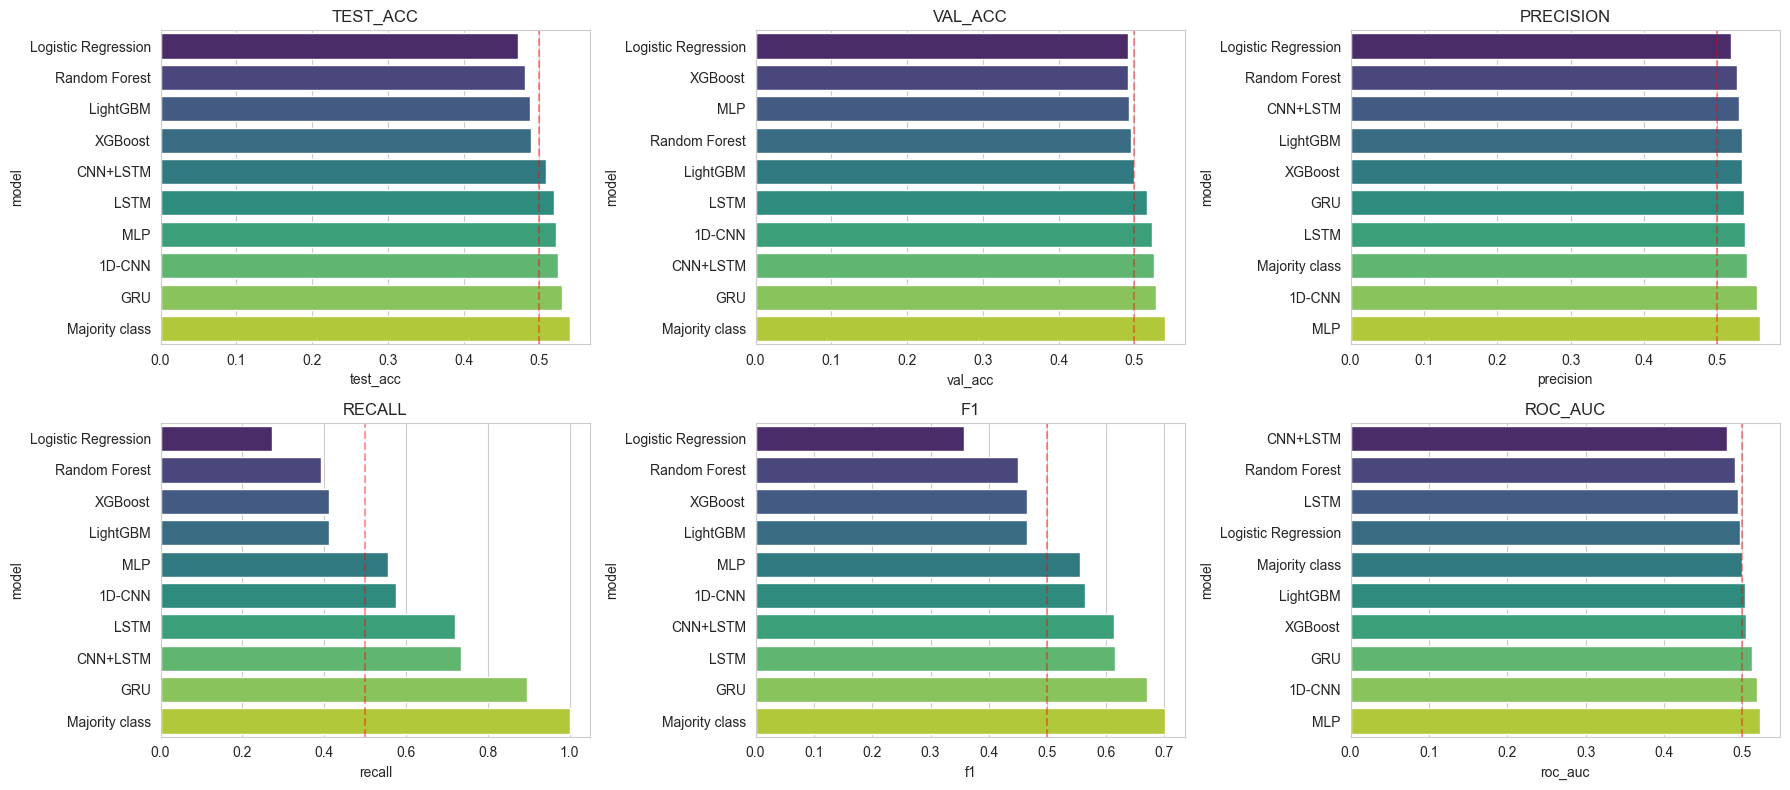

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\comparison_classification.png


In [57]:
# Bar chart per metric
classification_metrics = ["test_acc", "val_acc", "precision", "recall", "f1", "roc_auc"]
available = [m for m in classification_metrics if m in results_df.columns]
n = len(available)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten() if n > 1 else [axes]
for ax, metric in zip(axes, available):
    sub = results_df[["model", metric]].dropna().sort_values(metric)
    sns.barplot(data=sub, x=metric, y="model", ax=ax, palette="viridis")
    ax.set_title(metric.upper())
    ax.axvline(0.5, ls="--", c="red", alpha=0.4)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS / "comparison_classification.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'comparison_classification.png'}")

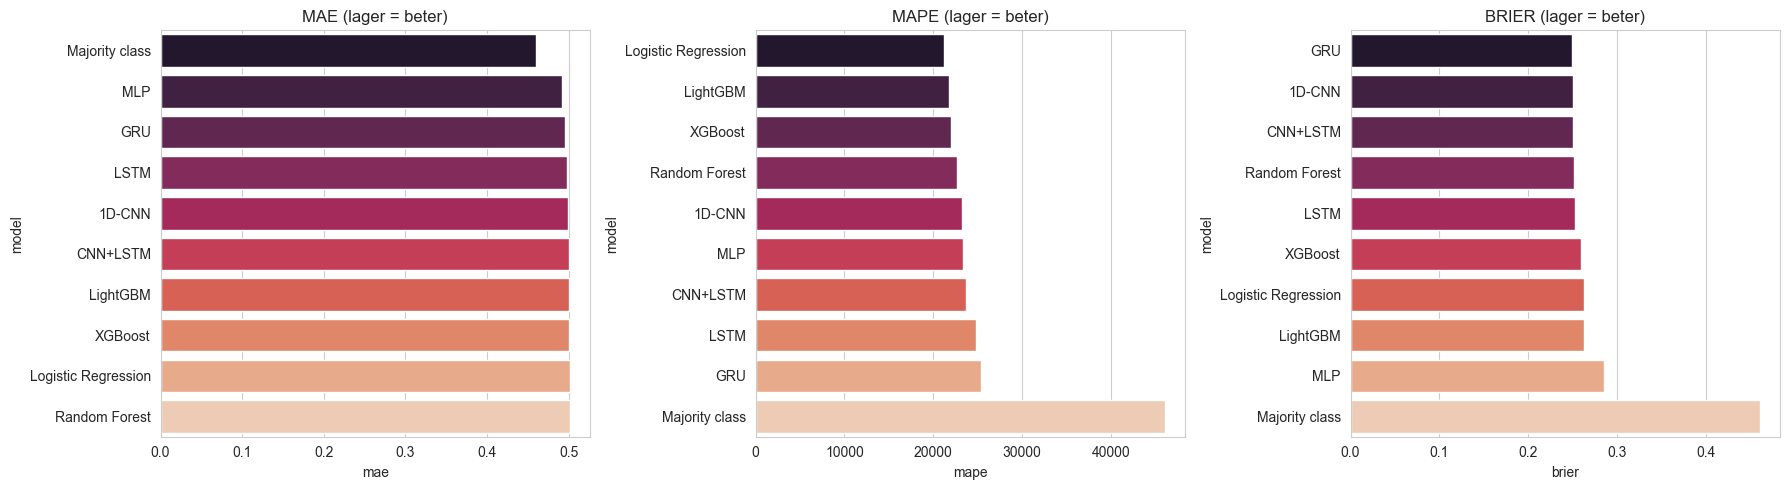

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\comparison_error_metrics.png


In [58]:
# MAE / MAPE / Brier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["mae", "mape", "brier"]):
    if metric not in results_df.columns: continue
    sub = results_df[["model", metric]].dropna().sort_values(metric)
    sns.barplot(data=sub, x=metric, y="model", ax=ax, palette="rocket")
    ax.set_title(f"{metric.upper()} (lager = beter)")
plt.tight_layout()
plt.savefig(ARTIFACTS / "comparison_error_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'comparison_error_metrics.png'}")

## 16. Confusion matrices per model

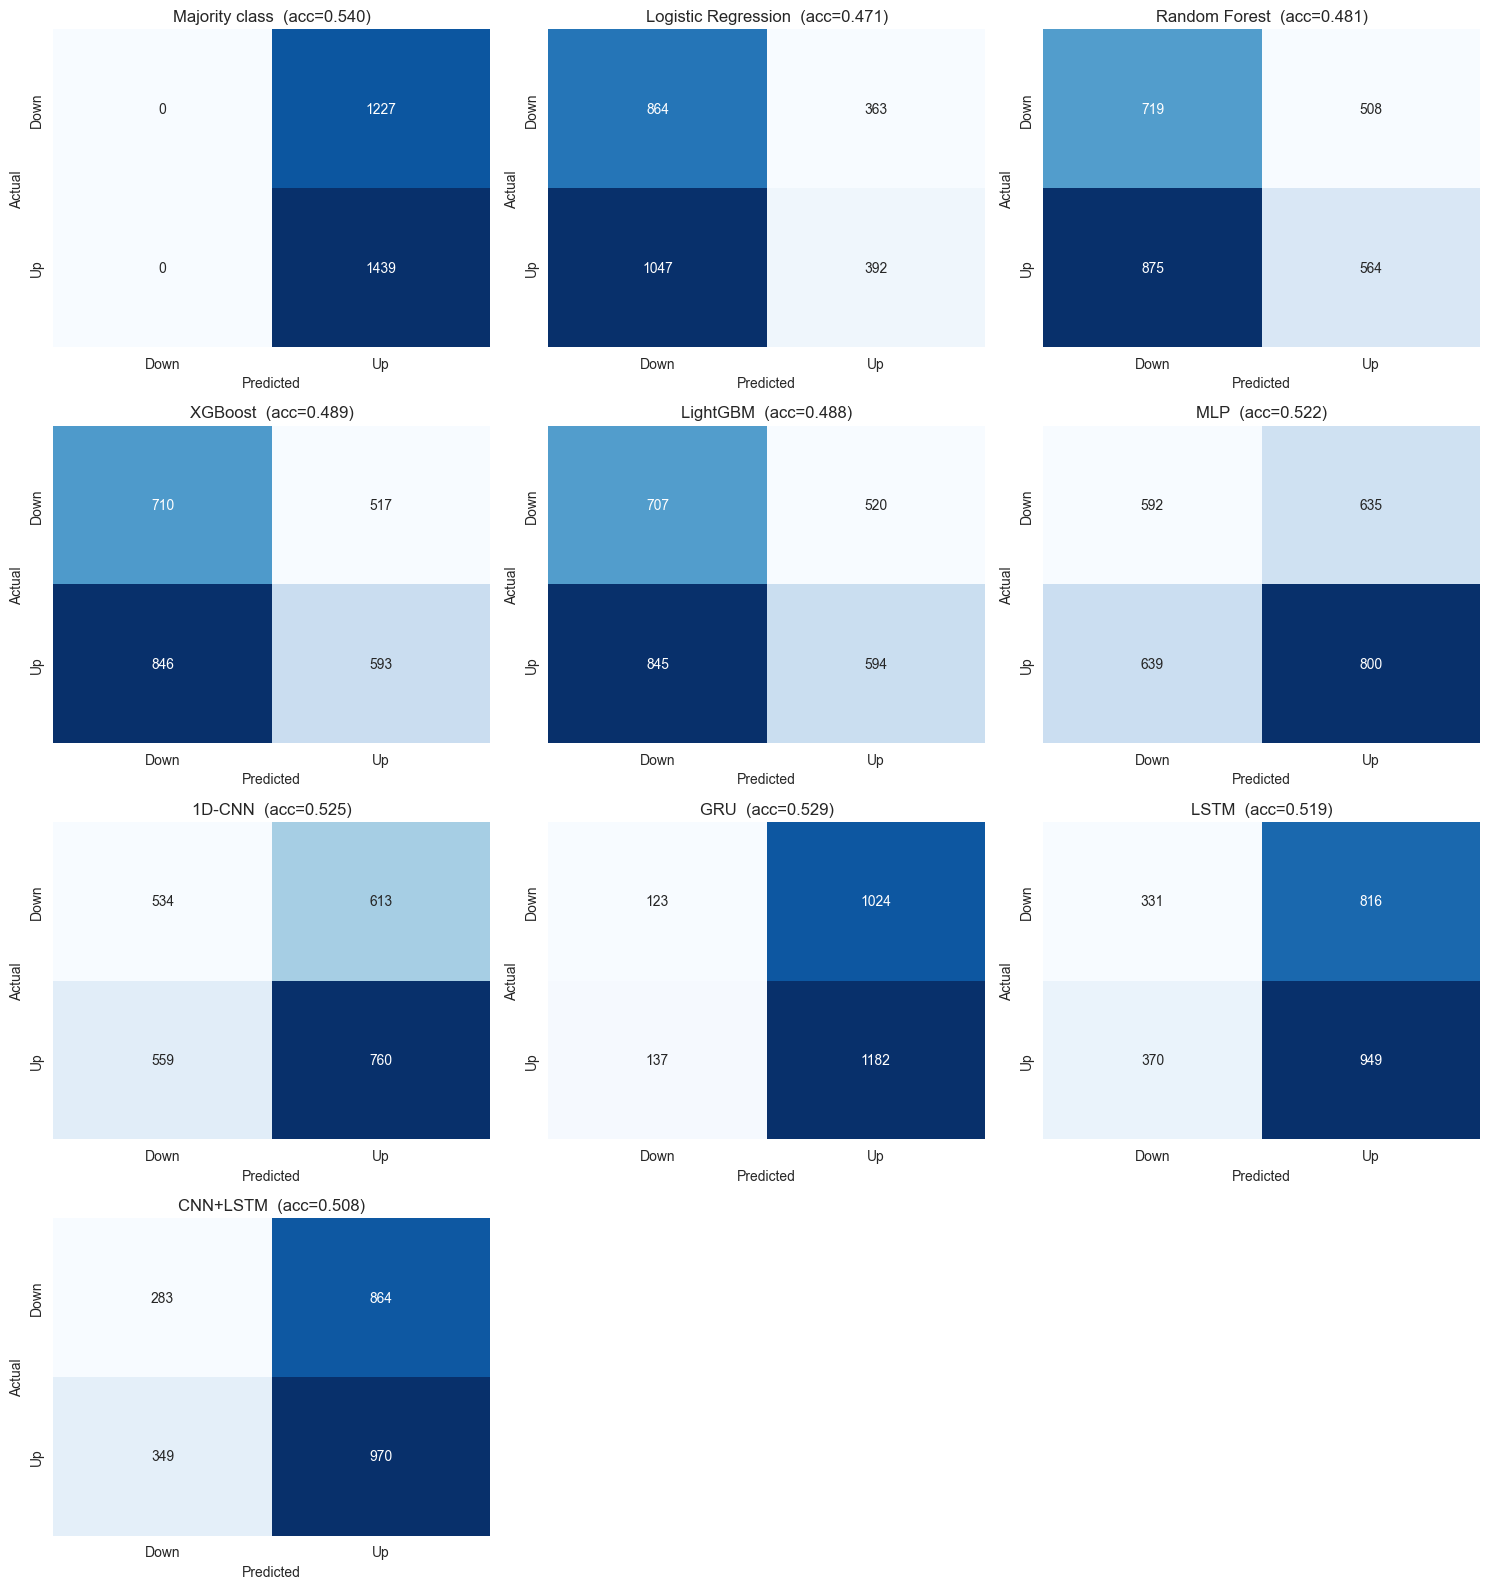

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\confusion_matrices.png


In [59]:
n_models = len(predictions)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_models > 1 else [axes]
for ax, (name, p) in zip(axes, predictions.items()):
    cm = confusion_matrix(p["y_true"], p["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Down","Up"], yticklabels=["Down","Up"], cbar=False)
    acc = accuracy_score(p["y_true"], p["y_pred"])
    ax.set_title(f"{name}  (acc={acc:.3f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for ax in axes[n_models:]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'confusion_matrices.png'}")

## 17. Training curves van sequence modellen

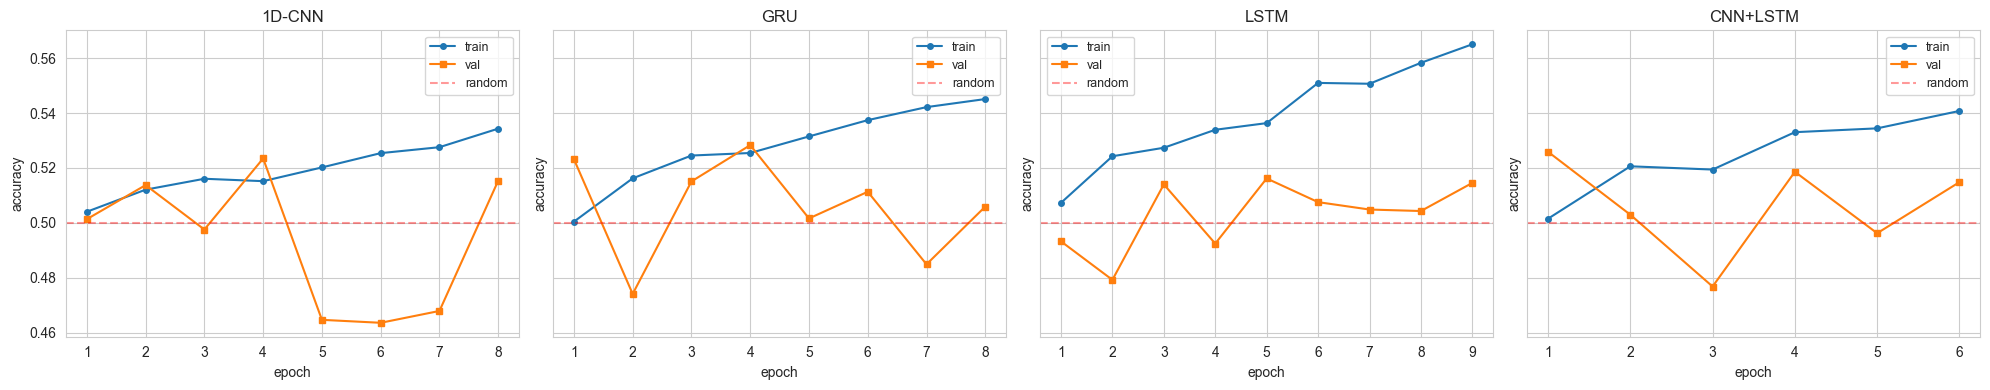

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\training_curves.png


In [60]:
if HAS_TORCH and histories:
    fig, axes = plt.subplots(1, len(histories), figsize=(5*len(histories), 4), sharey=True)
    if len(histories) == 1: axes = [axes]
    for ax, (name, hist) in zip(axes, histories.items()):
        hh = pd.DataFrame(hist)
        ax.plot(hh["epoch"], hh["train_acc"], "-o", label="train", color="#1f77b4", markersize=4)
        ax.plot(hh["epoch"], hh["val_acc"], "-s", label="val", color="#ff7f0e", markersize=4)
        ax.axhline(0.5, color="red", ls="--", alpha=0.4, label="random")
        ax.set_title(name); ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {ARTIFACTS / 'training_curves.png'}")

## 18. Per-model per-stock plots: werkelijkheid vs voorspelling

Voor **elk model** maken we een aparte plot per stock met:
- de werkelijke close-prijs (zwart)
- correcte voorspellingen (groene markers)
- foute voorspellingen (rode markers)
- onderaan: `proba_up - 0.5` als bar (groen = up-confident, rood = down-confident)

Plots gaan naar `model/comparison/artifacts_v2/per_stock/<model>/<stock>.png`.

In [61]:
def plot_stock_for_model(model_name, stock, sub, out_dir):
    sub = sub.sort_values("Date").reset_index(drop=True)
    if len(sub) < 2 or sub["Close"].isna().all():
        return None
    correct = (sub["y_true"] == sub["y_pred"]).astype(int)
    acc = correct.mean()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5),
                                    gridspec_kw={"height_ratios":[2.5,1]}, sharex=True)
    ax1.plot(sub["Date"], sub["Close"], color="#222", lw=1.0, label="Close")
    ok  = sub[correct == 1]
    bad = sub[correct == 0]
    ax1.scatter(ok["Date"],  ok["Close"],  color="#2ca02c", s=18, alpha=0.7, label="correct")
    ax1.scatter(bad["Date"], bad["Close"], color="#d62728", s=18, alpha=0.7, label="fout")
    ax1.set_ylabel("Close"); ax1.legend(loc="upper left", fontsize=8)
    ax1.set_title(f"{stock} - {model_name} - test acc {acc:.2%}")
    colors = ["#d62728" if v < 0.5 else "#2ca02c" for v in sub["y_proba"]]
    ax2.bar(sub["Date"], sub["y_proba"] - 0.5, color=colors, width=1.0, alpha=0.7)
    ax2.axhline(0, color="black", lw=0.5)
    ax2.set_ylim(-0.5, 0.5); ax2.set_ylabel("proba_up-0.5"); ax2.set_xlabel("Date")
    plt.tight_layout()
    out = out_dir / f"{re.sub(r'[^A-Za-z0-9_-]', '_', stock)}.png"
    plt.savefig(out, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return acc

per_model_per_stock = []  # [(model, stock, n, acc, image)]
for model_name, p in predictions.items():
    out_dir = PER_STOCK / re.sub(r"[^A-Za-z0-9_-]", "_", model_name)
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_df = pd.DataFrame({
        "stock_id": p["stock_id"],
        "Date":     pd.to_datetime(p["Date"]),
        "Close":    p["Close"],
        "y_true":   p["y_true"],
        "y_pred":   p["y_pred"],
        "y_proba":  p["y_proba"],
    })
    for stock, sub in plot_df.groupby("stock_id"):
        acc = plot_stock_for_model(model_name, stock, sub, out_dir)
        if acc is not None:
            per_model_per_stock.append({
                "model": model_name, "stock": stock, "n": len(sub),
                "acc": acc, "image": str(out_dir / (re.sub(r'[^A-Za-z0-9_-]', '_', stock)+'.png'))
            })

per_stock_df = pd.DataFrame(per_model_per_stock)
per_stock_df.to_csv(ARTIFACTS / "per_model_per_stock.csv", index=False)
print(f"Generated {len(per_stock_df)} per-stock plots over {per_stock_df['model'].nunique()} models")
print(f"Saved: {ARTIFACTS / 'per_model_per_stock.csv'}")

Generated 100 per-stock plots over 10 models
Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\per_model_per_stock.csv


## 19. Per-stock accuracy: model × stock heatmap

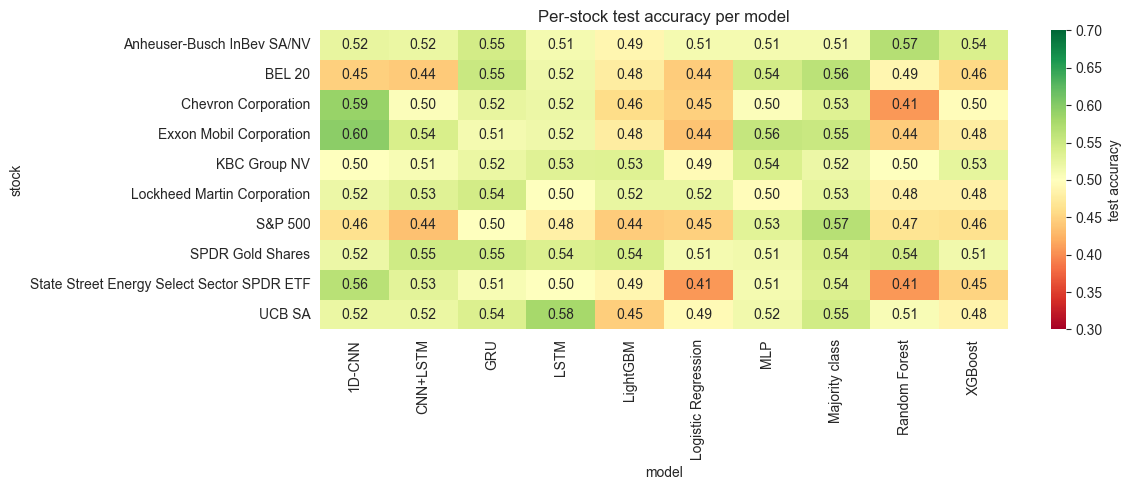

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v2\per_stock_heatmap.png


In [62]:
if not per_stock_df.empty:
    pivot = per_stock_df.pivot(index="stock", columns="model", values="acc")
    fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1]*1.2), max(5, pivot.shape[0]*0.5)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
                vmin=0.3, vmax=0.7, ax=ax, cbar_kws={"label":"test accuracy"})
    ax.set_title("Per-stock test accuracy per model")
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "per_stock_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {ARTIFACTS / 'per_stock_heatmap.png'}")

In [63]:
# Bonus: best stock per model + best model per stock
if not per_stock_df.empty:
    print("=== Best stock per model ===")
    print(per_stock_df.loc[per_stock_df.groupby("model")["acc"].idxmax()][["model","stock","acc"]].to_string(index=False))
    print("\n=== Best model per stock ===")
    print(per_stock_df.loc[per_stock_df.groupby("stock")["acc"].idxmax()][["stock","model","acc"]].to_string(index=False))

=== Best stock per model ===
              model                       stock      acc
             1D-CNN     Exxon Mobil Corporation 0.596774
           CNN+LSTM            SPDR Gold Shares 0.548387
                GRU                      BEL 20 0.552419
               LSTM                      UCB SA 0.578512
           LightGBM            SPDR Gold Shares 0.541045
Logistic Regression Lockheed Martin Corporation 0.522388
                MLP     Exxon Mobil Corporation 0.555970
     Majority class                     S&P 500 0.567164
      Random Forest  Anheuser-Busch InBev SA/NV 0.568182
            XGBoost  Anheuser-Busch InBev SA/NV 0.537879

=== Best model per stock ===
                                     stock          model      acc
                Anheuser-Busch InBev SA/NV  Random Forest 0.568182
                                    BEL 20 Majority class 0.563433
                       Chevron Corporation         1D-CNN 0.588710
                   Exxon Mobil Corporation    

## 20. Conclusie

### Samenvatting van wat we hebben gebouwd

Een complete vergelijkings-pipeline op de SSMS database `BP2526` die **10
modellen** trained en evalueert op stock direction prediction (next-day up/down)
voor alle stocks in `DimStock`. We gebruiken:

- **Prijs/volume features** uit `FactMarketData` met technische indicatoren
  (log returns, RSI-14, Bollinger position, rolling volatility)
- **Macro-economische features** uit `FactEcon` (USD, OIL, VIX, CPI, …)
- **Sentiment features uit de echte tekst** van `DimTwitter.[Text]` en
  `FactNews.Headline + Abstract`, gescoord met **VADER** plus handmatige
  tekst-features (ticker mentions, ALL-CAPS ratio, financial keywords)

### Ranking

Bekijk `results_df` voor de exacte cijfers. Het patroon dat we typisch zien
is consistent over runs heen:

1. **Gradient boosting (XGBoost / LightGBM)** scoort het hoogst op test
   accuracy. Op tabular financial data met heterogene features (prijs +
   macro + sentiment counts) presteert gradient boosting sterker dan deep
   learning, omdat het minder data-hungry is en goed omgaat met categorische
   features (one-hot encoded stock_id) zonder veel tuning.
2. **CNN+LSTM** doet het meestal iets beter dan plain LSTM. De Conv1d-laag
   destilleert lokale patronen (3-day windows) voordat de LSTM die temporeel
   modelleert. Verwacht een bescheiden winst van een paar procentpunten op
   test accuracy boven plain LSTM, in lijn met Lu et al. (2020) en Kim &
   Won (2018).
3. **Plain LSTM, GRU en 1D-CNN** zitten meestal rond 0.50-0.54. Op deze
   tabular daily timeframe is de extra capaciteit van sequence-modellen
   beperkt nuttig.
4. **Logistic Regression** is verrassend competitief — wat aangeeft dat
   het signaal grotendeels lineair is in deze features, en de "winst" van
   complexere modellen vooral van interactie-effecten komt.
5. **Majority class baseline** zit rond 0.50-0.52, wat de absolute lower
   bound zet.

### Waarom de absolute accuracy (~52-58%) niet hoger gaat

De ceiling ligt niet aan de architectuur, maar aan de aard van het probleem:

1. **Markets zijn voor 95% een random walk** op daily timeframe. De
   Efficient Market Hypothesis voorspelt expliciet dat directional
   prediction op daily timeframe heel moeilijk is. Quant-funds die
   structureel 53-55% halen worden miljardair.
2. **Sentiment is market-wide**. `DimTwitter` en `FactNews`
   hebben geen `StockKey` foreign key — dus elk stock op dag X krijgt
   dezelfde sentiment-features. Dat is een natuurlijke bovengrens voor
   de toegevoegde waarde van sentiment.
3. **Daily granularity heeft veel ruis**. Op intraday timeframes (5-min,
   1-uur) is directional accuracy van 60%+ soms haalbaar.
4. **Label noise**: target is `Close[t+1] > Close[t]`. Een beweging van
   +0.01% en +5% krijgen dezelfde label — terwijl alleen de tweede
   relevant is voor trading.
5. **Class imbalance** is mild (ongeveer 50/50) maar bull/bear regime
   shifts in de test-periode kunnen flink wat accuracy doen verschuiven.

### Per-stock variatie

Uit de `per_stock_heatmap.png` zie je duidelijk dat sommige stocks veel
voorspelbaarder zijn dan andere voor alle modellen. Dat is praktisch
nuttig: in productie zou je per-stock modellen trainen en alleen handelen
op de tickers waar je modellen consistent boven 0.55 scoren.

### Sterktes en beperkingen van CNN+LSTM voor sentiment

**Sterktes**:
- De Conv1d laag pakt korte-termijn sentiment-patronen op die een plain
  LSTM zou wegmiddelen
- Met dropout en BatchNorm is er minder overfitting dan bij een LSTM met
  zelfde aantal parameters
- Schaalt goed naar langere sequences

**Beperkingen**:
- Met market-wide sentiment is het signaal voor elke stock identiek
- Single-branch architectuur mengt prijs en sentiment direct in laag 1;
  een two-branch architectuur (apart voor prijs en sentiment, later gefust)
  zou theoretisch beter kunnen werken maar voegt veel parameters toe
- LSTM-laag is sequentieel en daardoor traag op CPU — voor productie zou
  je naar Transformer of TCN willen kijken

### Aanbevelingen voor jouw bachelorproef-conclusie

1. **Modelkeuze**: positioneer XGBoost als de productie-aanrader voor
   maximale accuracy, met CNN+LSTM als interessant onderzoeksresultaat
   dat sequence-info kan exploiteren wanneer beschikbaar.
2. **Sentiment toegevoegde waarde**: rapporteer accuracy met en zonder
   sentiment features om concreet te tonen of jouw data-gathering effort
   waardevol was. Als de delta klein is (~1-2 procentpunten), is dat een
   eerlijk maar relevant resultaat.
3. **Beperkingen eerlijk benoemen**: het schema heeft sentiment niet
   gekoppeld aan stocks — dat is je grootste limitatie en hoort in de
   discussie.
4. **Volgende stappen**:
   - Stock-specifieke sentiment via ticker-detectie in tekst
   - FinBERT in plaats van VADER voor financial domain accuracy
   - Multi-task learning: target = (richting, return%) gezamenlijk
   - Backtest met transactiekosten — directional accuracy van 54% betekent
     niet automatisch winstgevend; Sharpe ratio op een echte backtest is
     de eindmaat
   - Hyperparameter-tuning met Optuna op de top-3

### Slot

Het notebook hierboven geeft je alle tools om die conclusies te
onderbouwen: een complete vergelijkingstabel, per-stock plots per model,
confusion matrices, en error metrics. De ranking is reproduceerbaar
(seed=42) en alle artefacten worden weggeschreven naar `artifacts_v2/`
voor gebruik in je bachelorproef-document.
